In [1]:
# pip/conda install networkx matplotlib
import networkx as nx
import matplotlib.pyplot as plt

def draw_graph(graph, directed=False, weighted=False):
    G = nx.DiGraph() if directed else nx.Graph()

    for node, neighbours in graph.items():
        G.add_node(node)
        for neighbour in neighbours:
            if weighted:
                target, weight = neighbour
                G.add_edge(node, target, weight = weight)
            else:
                G.add_edge(node, neighbour)

    pos = nx.spring_layout(G, seed = 42)
    
    node_font_sizes = {
        node: max(6, min(12, 160 / len(str(node))))
        for node in G.nodes()
    }

    fig, ax = plt.subplots(figsize=(10, 8))

    nx.draw(
        G, pos,
        with_labels = True,
        node_color = "lightblue",
        node_size = 800,
        font_weight = "bold",
        font_size = node_font_sizes,
        arrows = directed,
        arrowsize = 20,
        min_source_margin = 10,
        min_target_margin = 10,
        ax = ax
    )

    if weighted:
        edge_labels = nx.get_edge_attributes(G, "weight")
        nx.draw_networkx_edge_labels(G, pos, edge_labels = edge_labels)

    ax.margins(0.15)    
    plt.show()

['B', 'C']


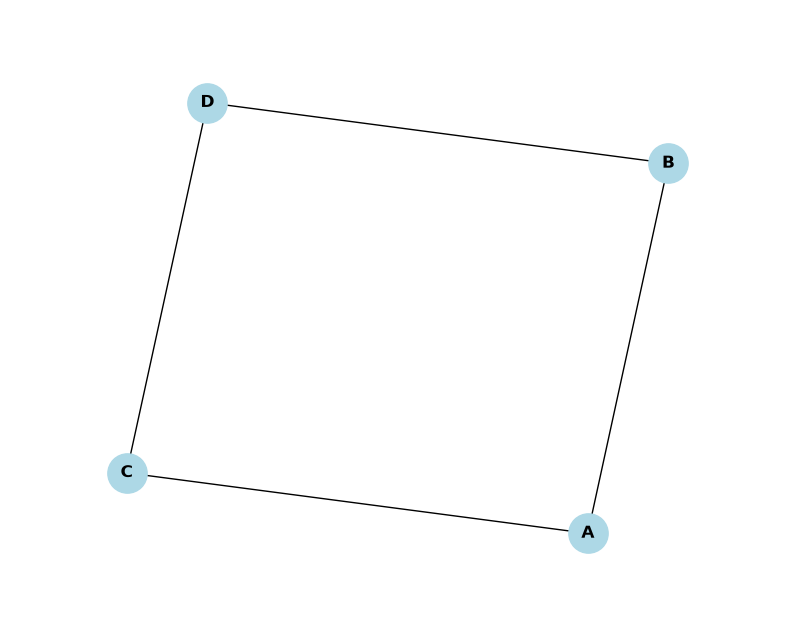

In [4]:
# A basic adjaceny list
graph = {
    "A": ["B", "C"],
    "B": ["A", "D"],
    "C": ["A", "D"],
    "D": ["B", "C"]
}

# Who are As neighbors?
print(graph["A"])
draw_graph(graph)

['Nebraska', 'Missouri', 'Oklahoma', 'Colorado']


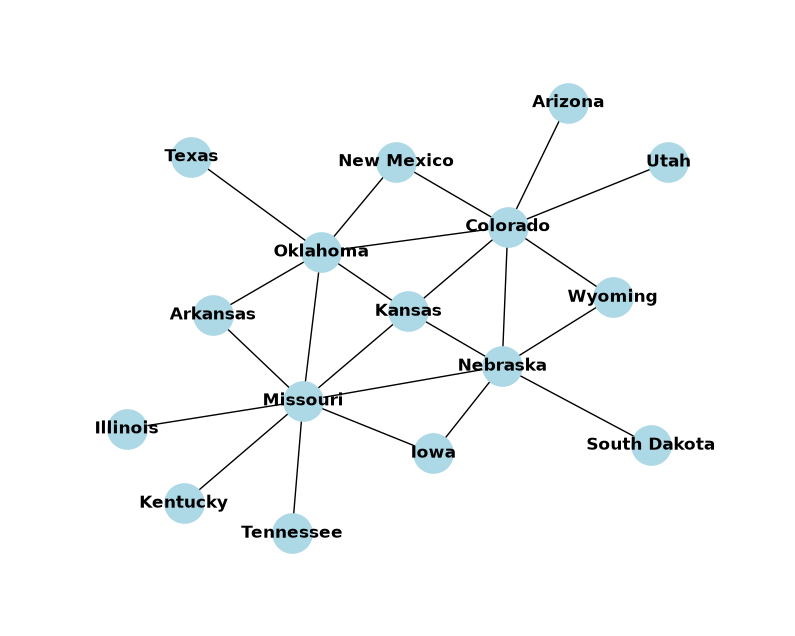

In [6]:
# Real life scenario/example
us_states = {
    "Kansas": ["Nebraska", "Missouri", "Oklahoma", "Colorado"],
    "Nebraska": ["Kansas", "Colorado", "Wyoming", "South Dakota", "Iowa", "Missouri"],
    "Missouri": ["Kansas", "Nebraska", "Iowa", "Illinois", "Kentucky", "Tennessee", "Arkansas", "Oklahoma"],
    "Oklahoma": ["Kansas", "Missouri", "Arkansas", "Texas", "New Mexico", "Colorado"],
    "Colorado": ["Kansas", "Nebraska", "Wyoming", "Utah", "Arizona", "New Mexico", "Oklahoma"]
}

# Who are Kansas' neighbours?
print(us_states["Kansas"])
draw_graph(us_states)

In [7]:
# Check for edge / connection
def are_connected(graph, node1, node2):
    return node2 in graph[node1]

# Return degree (number of edges) of Node/Vertex
def degree(graph, node):
    return len(graph[node])

In [8]:
print(are_connected(us_states, "Kansas", "Missouri"))
print(are_connected(us_states, "Kansas", "Kentucky"))

True
False


In [9]:
for node in us_states:
    print(f"{node} has degree {degree(us_states, node)}")

Kansas has degree 4
Nebraska has degree 6
Missouri has degree 8
Oklahoma has degree 6
Colorado has degree 7


In [10]:
for node in graph:
    print(f"{node} has degree {degree(graph, node)}")

A has degree 2
B has degree 2
C has degree 2
D has degree 2


['B', 'D']
['C', 'D']
[]


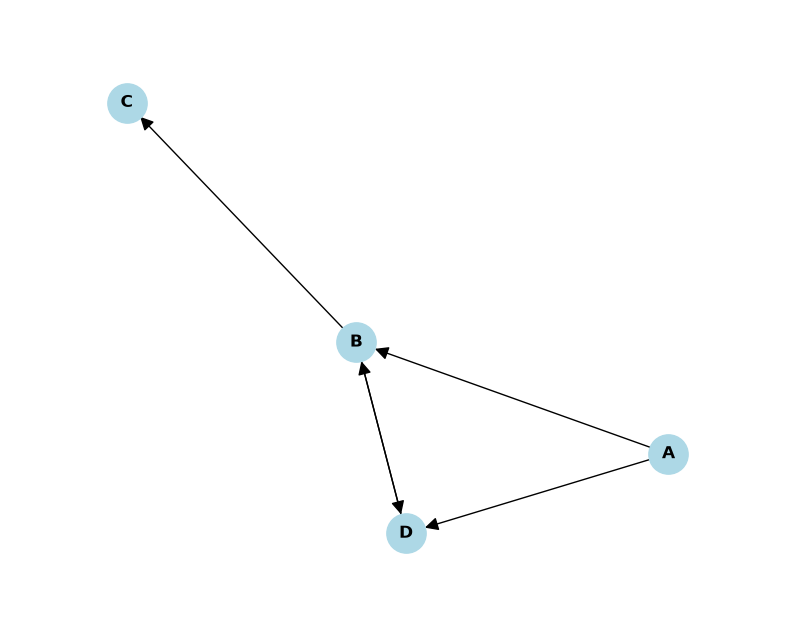

In [12]:
directed_graph = {
    "A": ["B", "D"],       # A -> B, but not B -> A
    "B": ["C", "D"],
    "C": [],
    "D": ["B"]
}

print(directed_graph["A"])
print(directed_graph["B"])
print(directed_graph["C"])

draw_graph(directed_graph, directed = True)

['Industriveien', 'Ofotveien']


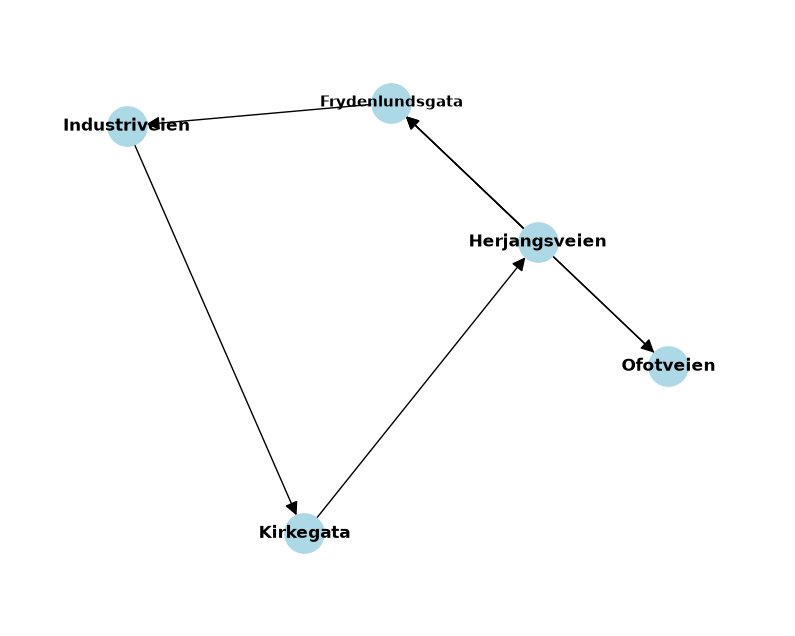

In [14]:
narvik_graph = {
    "Frydenlundsgata": ["Industriveien", "Ofotveien"],
    "Ofotveien": ["Frydenlundsgata"],
    "Herjangsveien": ["Frydenlundsgata"],
    "Industriveien": ["Kirkegata"],
    "Kirkegata": ["Herjangsveien"]
}

print(narvik_graph["Frydenlundsgata"])

draw_graph(narvik_graph, directed = True)

A -> B costs 4
A -> C costs 2


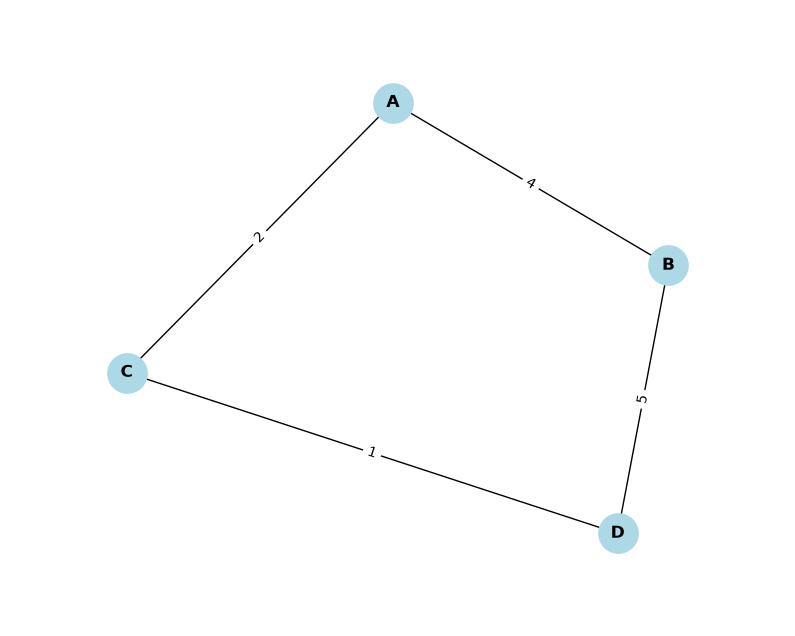

In [16]:
weighted_graph = {
    "A": [("B", 4), ("C", 2)],
    "B": [("A", 4), ("D", 5)],
    "C": [("A", 2), ("D", 1)],
    "D": [("B", 5), ("C", 1)]
}


# Print each neighbour with its cost
for neighbour, cost in weighted_graph["A"]:
    print(f"A -> {neighbour} costs {cost}")

draw_graph(weighted_graph, weighted = True)

In [19]:
class Node:
    def __init__(self, value):
        self.value = value
        self.neighbours = []

    def add_neighbour(self, node):
        if node not in self.neighbours:
            self.neighbours.append(node)

    def are_connected(self, node):
        return node in self.neighbours

    def degree(self):
        return len(self.neighbours)

    def __repr__(self):
        return self.value

# Create nodes
states = {
    "KS": Node("KS"),
    "NE": Node("NE"),
    "MO": Node("MO"),
    "OK": Node("OK"),
    "CO": Node("CO"),
}

# Add connections / Creating a Graph
states["KS"].add_neighbour(states["NE"])
states["KS"].add_neighbour(states["MO"])
states["KS"].add_neighbour(states["OK"])
states["KS"].add_neighbour(states["CO"])

states["NE"].add_neighbour(states["KS"])
states["NE"].add_neighbour(states["CO"])
states["NE"].add_neighbour(states["MO"])

states["MO"].add_neighbour(states["KS"])
states["MO"].add_neighbour(states["NE"])
states["MO"].add_neighbour(states["OK"])

states["OK"].add_neighbour(states["KS"])
states["OK"].add_neighbour(states["MO"])
states["OK"].add_neighbour(states["CO"])

states["CO"].add_neighbour(states["KS"])
states["CO"].add_neighbour(states["NE"])
states["CO"].add_neighbour(states["OK"])

# Main
ks = states["KS"]

print("State:", ks.value)
print("Neighbours:", ks.neighbours)
print("Degree:", ks.degree())

print("Connected to NE:", ks.are_connected(states["NE"]))
print("Connected to MO:", ks.are_connected(states["MO"]))
print("Connected to TX:", ks.are_connected(Node("TX")))

State: KS
Neighbours: [NE, MO, OK, CO]
Degree: 4
Connected to NE: True
Connected to MO: True
Connected to TX: False
